In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

#import numpy as np # linear algebra
#import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

#import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
 #   for filename in filenames:
  #      print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten,Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.metrics import Recall
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input

In [4]:
train_images = '/kaggle/input/retinal-disease-classification/Training_Set/Training_Set/Training'
train_labels = pd.read_csv("/kaggle/input/retinal-disease-classification/Training_Set/Training_Set/RFMiD_Training_Labels.csv")
val_images = '/kaggle/input/retinal-disease-classification/Evaluation_Set/Evaluation_Set/Validation'
val_labels = pd.read_csv("/kaggle/input/retinal-disease-classification/Evaluation_Set/Evaluation_Set/RFMiD_Validation_Labels.csv")
test_images = '/kaggle/input/retinal-disease-classification/Test_Set/Test_Set/Test'
test_labels = pd.read_csv("/kaggle/input/retinal-disease-classification/Test_Set/Test_Set/RFMiD_Testing_Labels.csv")

In [5]:
def load_images_and_labels(image_dir, labels_df):
    images = []
    labels = []
    for index, row in labels_df.iterrows():
        img_path = os.path.join(image_dir, f"{row['ID']}.png")
        if os.path.exists(img_path):
            img = cv2.imread(img_path)
            img = cv2.resize(img, (380, 380))
            img = img.astype('float32')
            images.append(img)
            labels.append(row[['Disease_Risk', 'DR', 'ODC', 'TSLN']].values.astype(np.float32))
    
    return np.array(images), np.array(labels)

In [6]:
X_train, y_train = load_images_and_labels(train_images, train_labels)

In [7]:
X_val, y_val = load_images_and_labels(val_images, val_labels)

In [8]:
SEED = 42
import random
import numpy as np
import tensorflow as tf

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [9]:
datagen = ImageDataGenerator(
    rotation_range=20,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    preprocessing_function=preprocess_input
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [10]:
train_generator = datagen.flow(X_train, y_train, batch_size=16,seed=SEED)
val_generator = val_datagen.flow(X_val, y_val, batch_size=16,seed=SEED)

In [11]:
base_model = EfficientNetB4(weights='imagenet', include_top=False, input_shape=(380, 380, 3))

I0000 00:00:1748762638.067865      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1748762638.068503      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [20]:
x = Flatten()(base_model.output)

x = Dense(24)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.3)(x)

x = Dense(4, activation='sigmoid')(x) 

In [21]:
for layer in base_model.layers:
    layer.trainable = False

In [22]:
model = Model(inputs=base_model.input, outputs=x)

In [23]:
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy',Recall(name='recall')])

In [24]:
from tensorflow.keras.callbacks import Callback

class RecallGapEarlyStopping(Callback):
    def __init__(self, patience=3, min_gap=0.1):
        super().__init__()
        self.patience = patience
        self.min_gap = min_gap
        self.wait = 0

    def on_epoch_end(self, epoch, logs=None):
        recall = logs.get("recall")
        val_recall = logs.get("val_recall")

        if recall is None or val_recall is None:
            print("⚠️ تأكد من أنك تستخدم metric=Recall() أثناء compile.")
            return

        gap = recall - val_recall
        print(f"🔎 Epoch {epoch + 1}: recall = {recall:.4f}, val_recall = {val_recall:.4f}, gap = {gap:.4f}")

        if gap > self.min_gap:
            self.wait += 1
            if self.wait >= self.patience:
                print(f"\n⛔️ تم الإيقاف: الفجوة بين recall و val_recall تجاوزت {self.min_gap} لـ {self.patience} مرات.")
                self.model.stop_training = True
        else:
            self.wait = 0


In [25]:
recall_gap_stop = RecallGapEarlyStopping(patience=2, min_gap=0.05)

In [27]:
history = model.fit(train_generator, epochs=20 ,validation_data=val_generator, callbacks=[recall_gap_stop])

Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.3699 - loss: 0.6424 - recall: 0.3588🔎 Epoch 1: recall = 0.3936, val_recall = 0.4258, gap = -0.0322
120/120 ━━━━━━━━━━━━━━━━━━━━ 69s 573ms/step - accuracy: 0.3710 - loss: 0.6419 - recall: 0.3591 - val_accuracy: 0.7844 - val_loss: 0.4219 - val_recall: 0.4258
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.8103 - loss: 0.4334 - recall: 0.5440🔎 Epoch 2: recall = 0.5667, val_recall = 0.7058, gap = -0.1392
120/120 ━━━━━━━━━━━━━━━━━━━━ 57s 477ms/step - accuracy: 0.8107 - loss: 0.4333 - recall: 0.5442 - val_accuracy: 0.9953 - val_loss: 0.3251 - val_recall: 0.7058
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.9279 - loss: 0.3779 - recall: 0.6228🔎 Epoch 3: recall = 0.6390, val_recall = 0.6439, gap = -0.0049
120/120 ━━━━━━━━━━━━━━━━━━━━ 57s 475ms/step - accuracy: 0.9279 - loss: 0.3778 - recall: 0.6229 - val_accuracy: 0.9937 - val_loss: 0.3301 - val_recall: 0.6439
Epoch 4/20
120/120 ━━━━━━

In [ ]:
# Save the trained model so it can be used by the RetinaScan AI interface.
# Download this file from the Kaggle output panel after running,
# then place it at:  retinal-disease-classifier/model/retinal_model.h5
model.save("retinal_model.h5")
print("Saved model to retinal_model.h5")


In [28]:
def display_training_curves(training, validation, title, subplot):
    if subplot%10==1: # set up the subplots on the first call
        plt.subplots(figsize=(10,10), facecolor='#F0F0F0')
        plt.tight_layout()
    ax = plt.subplot(subplot)
    ax.set_facecolor('#F8F8F8')
    ax.plot(training)
    ax.plot(validation)
    ax.set_title('model '+ title)
    ax.set_ylabel(title)
    ax.set_xlabel('epoch')
    ax.legend(['train', 'valid.'])

In [29]:
plt.style.use('ggplot')

def plot_history(history):
    recall = history.history['recall']
    val_recall = history.history['val_recall']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    x = range(1, len(recall) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, recall, 'b', label='Training recall')
    plt.plot(x, val_recall, 'r', label='Validation recall')
    plt.title('Training and validation recall')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(x, loss, 'b', label='Training loss')
    plt.plot(x, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()
 

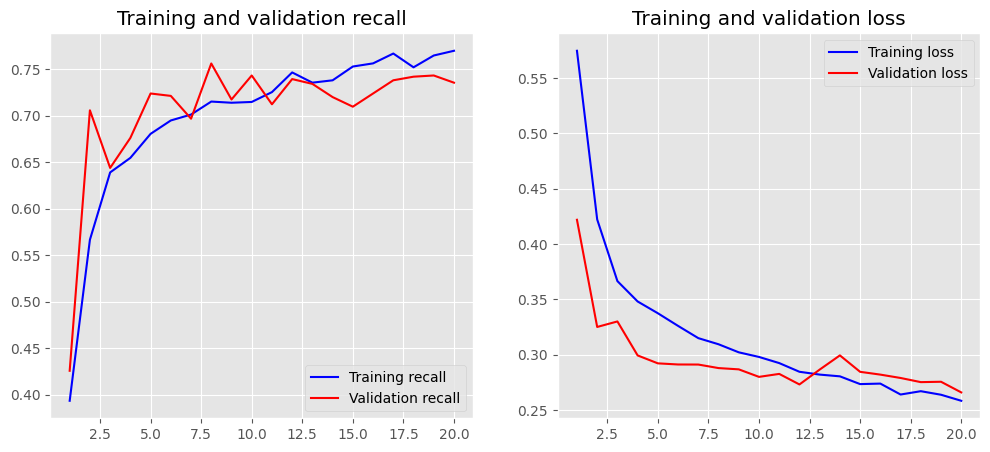

In [30]:
plot_history(history)

In [31]:
plt.style.use('ggplot')

def plot_history2(history):
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    x = range(1, len(accuracy) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, accuracy, 'b', label='Training accuracy')
    plt.plot(x, val_accuracy, 'r', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(x, loss, 'b', label='Training loss')
    plt.plot(x, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()
 

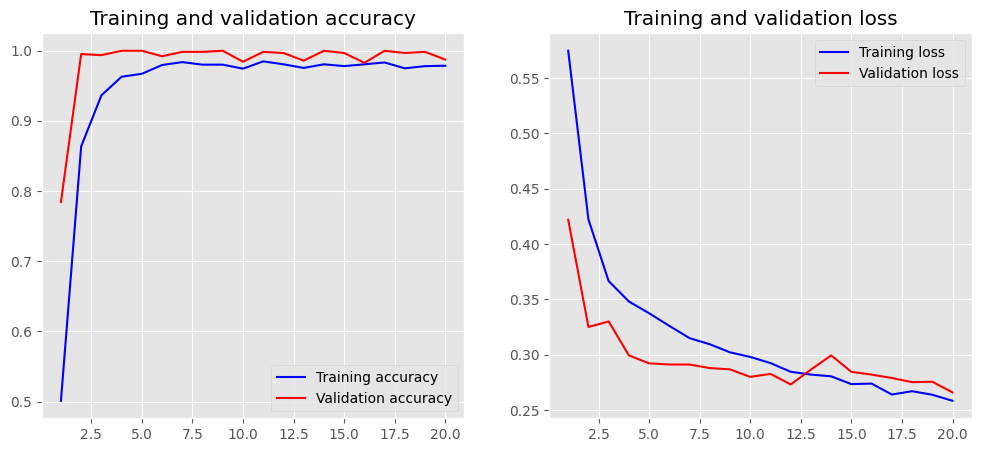

In [32]:
plot_history2(history)

In [33]:
loss, accuracy,recall = model.evaluate(val_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Recall: {recall:.4f}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - accuracy: 0.9923 - loss: 0.2693 - recall: 0.7560
Validation Loss: 0.2660
Validation Accuracy: 0.9875
Validation Recall: 0.7355


In [34]:
X_test, y_test = load_images_and_labels(test_images, test_labels)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_generator = test_datagen.flow(X_test, y_test, batch_size=32, shuffle=False)

In [36]:
test_loss, test_accuracy,test_recall = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test_Recall: {test_recall:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 291ms/step - accuracy: 0.9953 - loss: 0.2556 - recall: 0.7550
Test Loss: 0.2608
Test Accuracy: 0.9797
Test_Recall: 0.7235


In [95]:
img_path = '/kaggle/input/retinal-disease-classification/Test_Set/Test_Set/Test/371.png'

In [96]:
img = cv2.imread(img_path)
img = cv2.resize(img, (380, 380))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

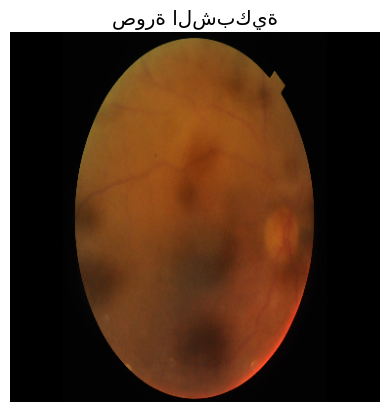

In [97]:
plt.imshow(img_rgb)
plt.axis('off')
plt.title("صورة الشبكية")
plt.show()

In [98]:
img_array = np.expand_dims(img_rgb, axis=0)
img_array = preprocess_input(img_array)

In [99]:
predictions = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


In [100]:
predicted_labels = (predictions > 0.7).astype(int)

In [101]:
print(predictions)

[[0.99875164 0.1695449  0.09209368 0.07445358]]


In [102]:
print(predicted_labels)

[[1 0 0 0]]
